# Bike Rental Prediction

## Problem Statement 
The objective of this project is to predict the daily bike rental count (cnt)
based on environmental and seasonal factors such as weather conditions,
temperature, humidity, wind speed, and calendar-based attributes.

This is a regression problem, and the goal is to build and compare multiple
machine learning models to identify the best-performing model for production use.

## Import Required Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

#Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score,r2_score, mean_squared_error, mean_absolute_error

In [2]:
# Load both datasets
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

print("Day dataset shape:", day_df.shape)
print("Hour dataset shape:", hour_df.shape)


Day dataset shape: (731, 16)
Hour dataset shape: (17379, 17)


### Dataset Structure Comparison

In [3]:
# Compare columns
print("Extra column in hour dataset:")
set(hour_df.columns) - set(day_df.columns)


Extra column in hour dataset:


{'hr'}

### Dataset Selection Justification 
The Bike Sharing dataset provides two files:
 hour.csv – hourly level bike rental data
 day.csv – daily aggregated bike rental data

Since the problem statement explicitly requires prediction of daily bike rental
count, the day.csv dataset is the correct choice for modeling.

Using hourly data would introduce unnecessary granularity mismatch and potential
data leakage. Therefore:
 hour.csv is used only for structural understanding
 day.csv is used for EDA, feature engineering, model training, and evaluation

In [4]:
# Use daily dataset for further analysis
df = day_df.copy()

# Drop record identifier column
df.drop(columns=["instant"], inplace=True)

df.head()


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Data Preprocessing 

### Dataset Shape & Information

In [5]:
df.shape

(731, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      731 non-null    object 
 1   season      731 non-null    int64  
 2   yr          731 non-null    int64  
 3   mnth        731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 85.8+ KB


## Missing Values & Duplicates Check

In [7]:
df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Statistical Summary

In [9]:
df.describe()


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Observation
1) No missing values were found in the dataset
2) No duplicate records exist
3) The dataset is clean and suitable for exploratory data analysis

## Exploratory Data Analysis (EDA)

### Convert Date Column

In [10]:
# Convert date column to datetime format
day_df["dteday"] = pd.to_datetime(day_df["dteday"])


### Trend of Bike Rentals Over Time

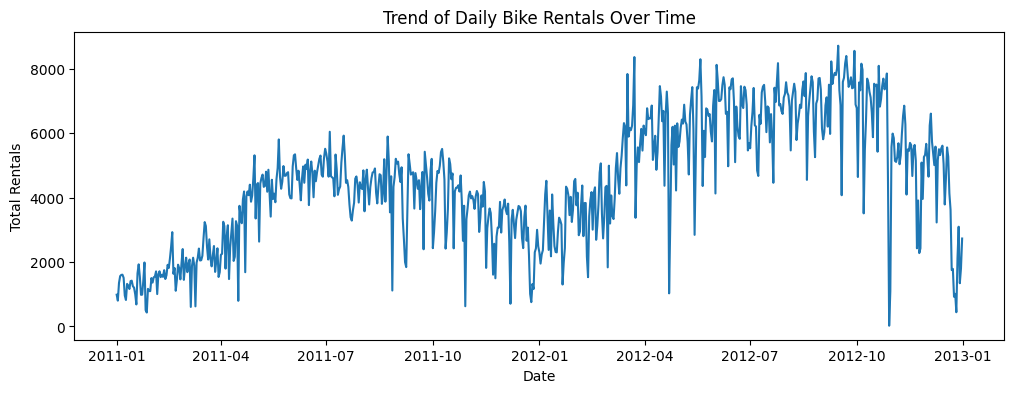

In [11]:
plt.figure(figsize=(12,4))
plt.plot(day_df["dteday"], day_df["cnt"])
plt.title("Trend of Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.show()


### Rentals by Season

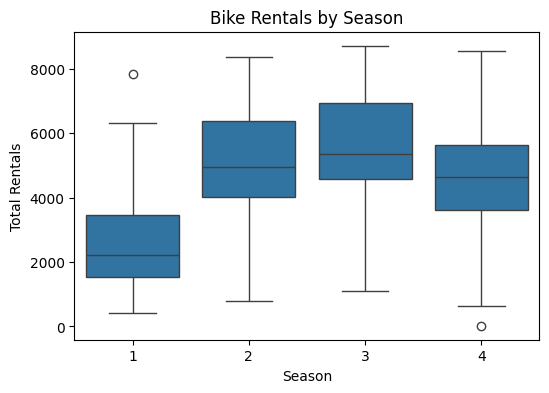

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="season", y="cnt", data=day_df)
plt.title("Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Total Rentals")
plt.show()


### Rentals by Working Day

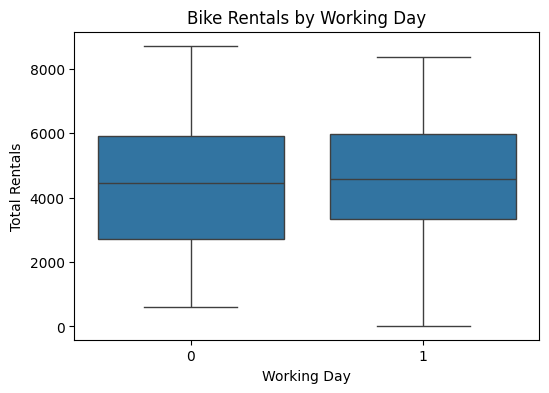

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="workingday", y="cnt", data=day_df)
plt.title("Bike Rentals by Working Day")
plt.xlabel("Working Day")
plt.ylabel("Total Rentals")
plt.show()


### Rentals by Holiday

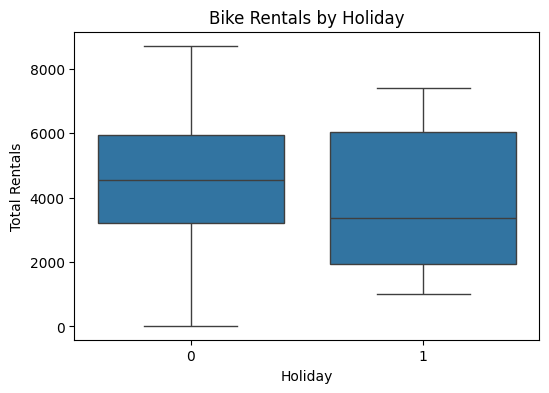

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="holiday", y="cnt", data=day_df)
plt.title("Bike Rentals by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Total Rentals")
plt.show()


### Rentals vs Temperature

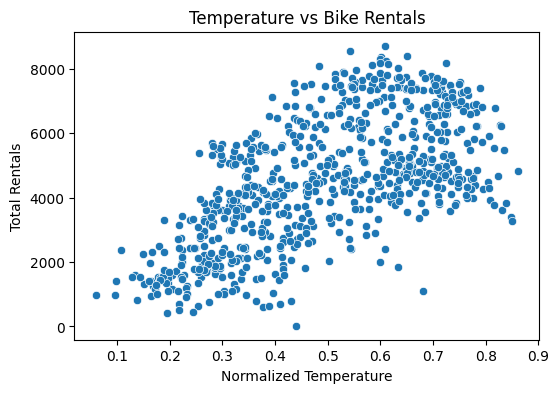

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="temp", y="cnt", data=day_df)
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Rentals")
plt.show()


### Rentals vs Humidity

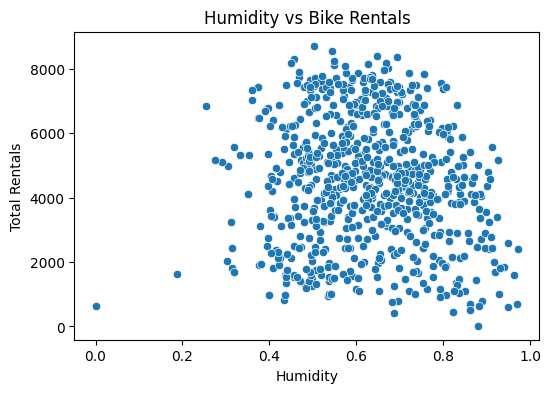

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="hum", y="cnt", data=day_df)
plt.title("Humidity vs Bike Rentals")
plt.xlabel("Humidity")
plt.ylabel("Total Rentals")
plt.show()


### Rentals vs Wind Speed

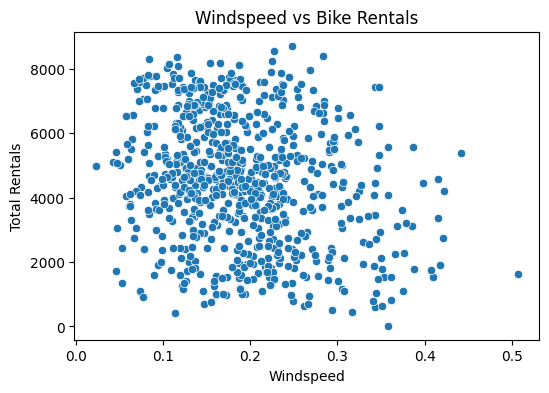

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="windspeed", y="cnt", data=day_df)
plt.title("Windspeed vs Bike Rentals")
plt.xlabel("Windspeed")
plt.ylabel("Total Rentals")
plt.show()


### Hourly Rental Pattern Using hour.csv

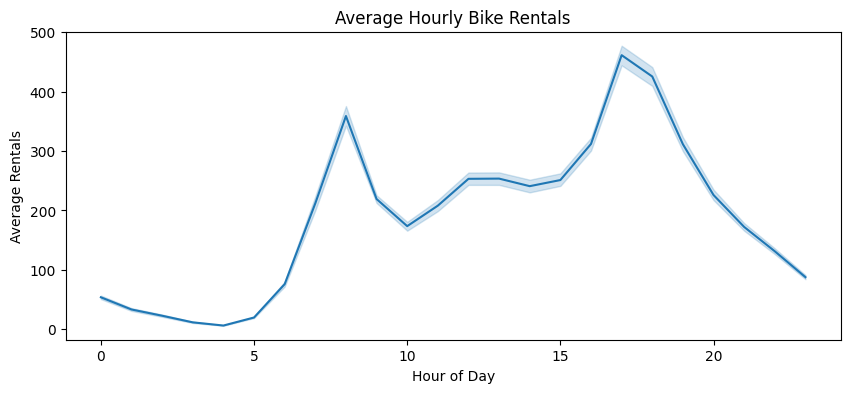

In [18]:
plt.figure(figsize=(10,4))
sns.lineplot(x="hr", y="cnt", data=hour_df, estimator="mean")
plt.title("Average Hourly Bike Rentals")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.show()


## EDA Observation 
1) Bike rentals show an overall increasing trend over time, indicating growth in bike-sharing usage.
2) Higher bike rentals are observed during summer and fall compared to winter,suggesting strong seasonal influence.
3) Working days generally show higher rentals, indicating regular commuting usage.
4) Bike rentals tend to be lower on holidays compared to non-holidays.
5) Bike rentals increase as temperature rises, showing a positive relationship.
6) Higher humidity levels are generally associated with slightly lower bike rentals.
7) Very high wind speeds tend to reduce bike rental usage.
8) Two rental peaks are visible—one in the morning and one in the evening—indicating
commuting behavior.

  

## Outlier Detection & Handling

### Numerical Columns Selection

In [19]:
numerical_cols = ["temp", "atemp", "hum", "windspeed"]


### Boxplots for Outlier Detection

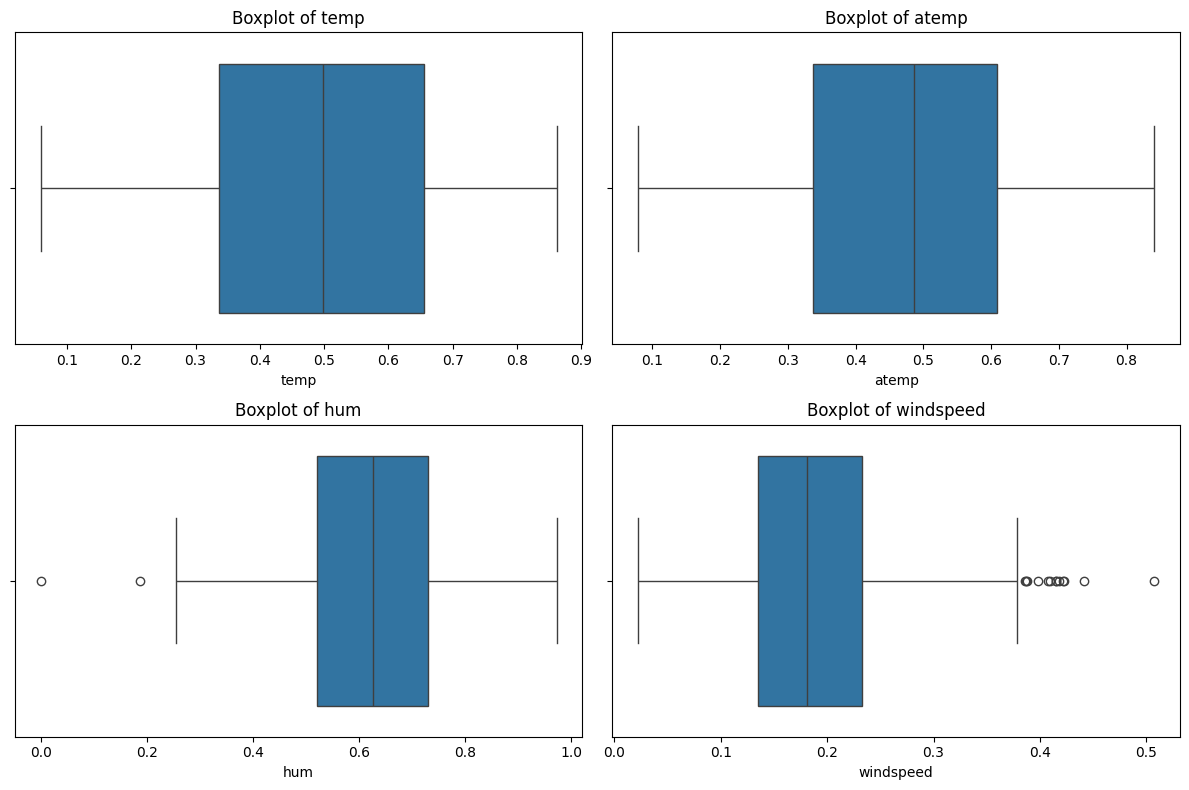

In [20]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=day_df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


### Outlier Treatment Using IQR

In [21]:
# Create a copy for outlier handling
outlier_df = day_df.copy()

def iqr_capping(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower, lower,
                           np.where(df[column] > upper, upper, df[column]))

for col in numerical_cols:
    iqr_capping(outlier_df, col)


### Boxplots After Outlier Treatment

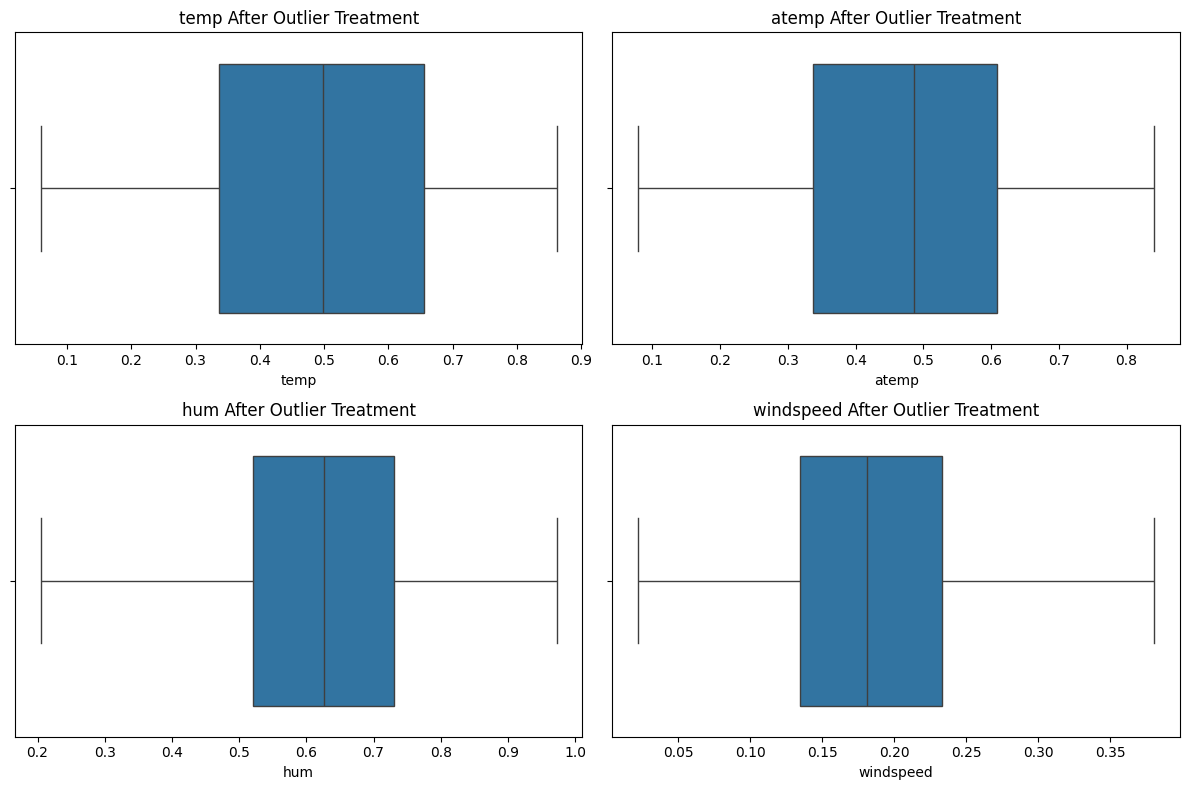

In [22]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=outlier_df[col])
    plt.title(f"{col} After Outlier Treatment")

plt.tight_layout()
plt.show()


### Outlier Handling Justification
- Outliers were treated using IQR-based capping
- No rows were removed to avoid data loss
- The target variable (cnt) was not treated for outliers because
  high rental values represent genuine demand peaks

This approach ensures robustness while preserving real-world behavior.

## Correlation Analysis & Feature Engineering

In [23]:
# Create a working copy for feature engineering
df = day_df.copy()


### Correlation Among Input Features

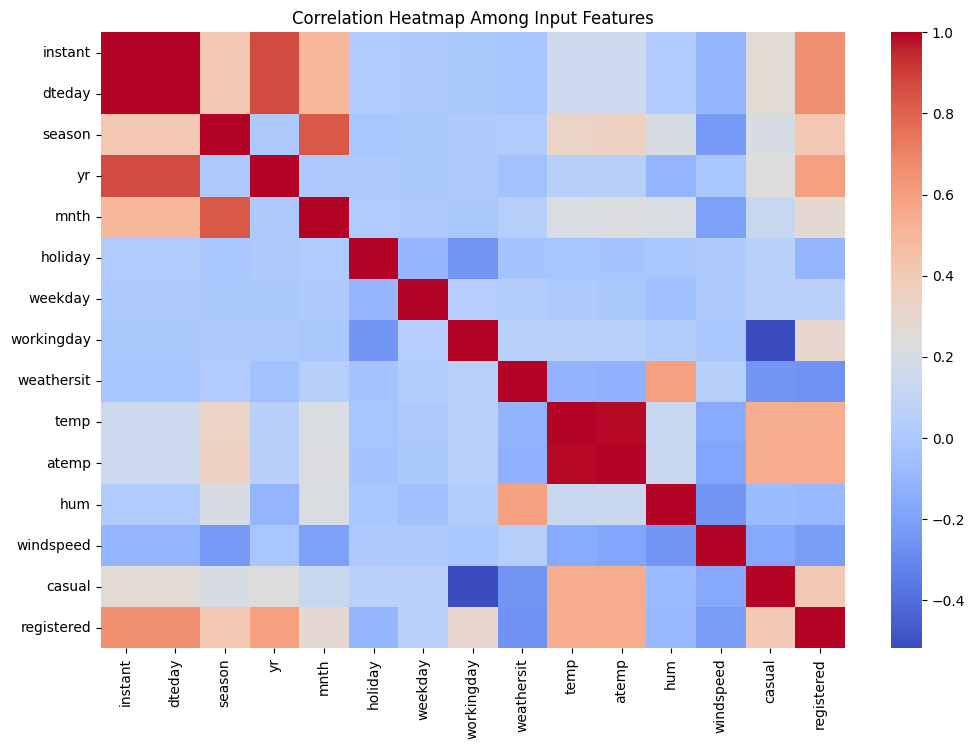

In [24]:
# Correlation among input features (excluding target)
input_corr = df.drop(columns=["cnt"]).corr()

plt.figure(figsize=(12,8))
sns.heatmap(input_corr, cmap="coolwarm")
plt.title("Correlation Heatmap Among Input Features")
plt.show()


### High Correlation Observation
The correlation heatmap shows a strong positive correlation between temp and atemp.
Since both features represent temperature-related information, keeping both may lead
to multicollinearity issues, especially for linear models.

To address this, atemp will be removed during feature engineering.


### Correlation With Target Variable

In [25]:
# Correlation of all features with target variable
target_corr = df.corr()["cnt"].sort_values(ascending=False)
target_corr


cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
dteday        0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64

### Correlation With Target Variable Observation
The correlation values show how strongly each feature is linearly related to the
target variable (cnt).

Features with lower correlation were not removed automatically, because:
- Correlation captures only linear relationships
- Tree-based models can capture non-linear patterns

Correlation analysis was therefore used as a supporting tool, not the sole
feature elimination criterion.


### Feature Engineering: Remove Leakage & Redundant Features

In [26]:
# Remove non-informative and leakage features
df.drop(columns=["instant", "dteday", "casual", "registered", "atemp"], inplace=True)

df.head()


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600


### Feature Engineering Summary
The following feature engineering steps were applied:

- Removed instant as it is only a record identifier
- Removed casual and registered to prevent data leakage
- Removed atemp due to high correlation with temp
- Retained all remaining features to preserve predictive information

These steps help improve model stability and generalization.

### Separate Features and Target

In [27]:
X = df.drop(columns=["cnt"])
y = df["cnt"]


### Encode Categorical Variables

In [28]:
# One-hot encoding for categorical features
X = pd.get_dummies(X, drop_first=True)

X.head()


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900


## Correlation and Feature Engineer Summary 
- Correlation analysis identified highly correlated input features
- Multicollinearity was reduced by removing redundant variables
- Low correlation with target was handled carefully to avoid information loss
- Feature engineering steps were applied systematically to prepare data for modeling


## Model Building & Evaluation

### Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
X_train

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed
682,4,1,11,0,2,1,2,0.343333,0.662917,0.342046
250,3,0,9,0,4,1,3,0.633913,0.939565,0.192748
336,4,0,12,0,6,0,1,0.299167,0.612917,0.095783
260,3,0,9,0,0,0,1,0.507500,0.695000,0.178483
543,3,1,6,0,3,1,1,0.697500,0.360000,0.271775
...,...,...,...,...,...,...,...,...,...,...
71,1,0,3,0,0,0,1,0.384348,0.527391,0.270604
106,2,0,4,0,0,0,1,0.456667,0.479583,0.303496
270,4,0,9,0,3,1,2,0.635000,0.848750,0.148629
435,1,1,3,0,0,0,1,0.361739,0.476957,0.222587


In [31]:
y_train

682    4094
250    1842
336    3614
260    4274
543    7335
       ... 
71     2417
106    3744
270    3907
435    4911
102    2162
Name: cnt, Length: 584, dtype: int64

### Evaluation Function

In [32]:
def evaluate_model(model):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    return {
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "MAE": mean_absolute_error(y_test, test_pred)
    }

### Linear Regression

In [33]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_metrics = evaluate_model(lr)
lr_metrics


{'Train_R2': 0.7895023572888796,
 'Test_R2': 0.8270447850465307,
 'RMSE': np.float64(832.7845178436388),
 'MAE': 620.6250906069755}

### Decision Tree Regressor

In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt_metrics = evaluate_model(dt)
dt_metrics


{'Train_R2': 1.0,
 'Test_R2': 0.812545656893666,
 'RMSE': np.float64(866.9889562965241),
 'MAE': 614.1904761904761}

### Random Forest Regressor

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf_metrics = evaluate_model(rf)
rf_metrics


{'Train_R2': 0.9822990113723035,
 'Test_R2': 0.8831729701948364,
 'RMSE': np.float64(684.4433049154162),
 'MAE': 431.95727891156463}

### Gradient Boosting Regressor

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb_metrics = evaluate_model(gb)
gb_metrics


{'Train_R2': 0.9511944728579708,
 'Test_R2': 0.8979250856120609,
 'RMSE': np.float64(639.7721401505929),
 'MAE': 445.4118419739023}

### Support Vector Regressor (SVR)

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR()
svr.fit(X_train_scaled, y_train)

y_test_pred = svr.predict(X_test_scaled)

svr_metrics = {
    "Train_R2": svr.score(X_train_scaled, y_train),
    "Test_R2": r2_score(y_test, y_test_pred),
    "MAE": mean_absolute_error(y_test, y_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
}

svr_metrics


{'Train_R2': 0.02385266624945037,
 'Test_R2': 0.0027486127240946567,
 'MAE': 1692.7922157549824,
 'RMSE': np.float64(1999.715148490639)}

### K-Nearest Neighbors Regressor

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor


knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

knn_metrics = evaluate_model(knn_scaled)
knn_metrics


{'Train_R2': 0.8564964802500662,
 'Test_R2': 0.800342324813473,
 'RMSE': np.float64(894.7646481115602),
 'MAE': 655.5360544217687}

## Models Summary
- Multiple regression models were trained separately
- Train vs test R² comparison revealed overfitting in tree-based models
- Ensemble methods performed better than linear models
- Hyperparameter tuning is required to further improve generalization

## Model Comparison Table

In [39]:
model_comparison = pd.DataFrame([
    {"Model": "Linear Regression", **lr_metrics},
    {"Model": "Decision Tree", **dt_metrics},
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "Gradient Boosting", **gb_metrics},
    {"Model": "SVR", **svr_metrics},
    {"Model": "KNN", **knn_metrics},
])

model_comparison


,Model,Train_R2,Test_R2,RMSE,MAE
0,Linear Regression,0.789502,0.827045,832.784518,620.625091
1,Decision Tree,1.000000,0.812546,866.988956,614.190476
2,Random Forest,0.982299,0.883173,684.443305,431.957279
3,Gradient Boosting,0.951194,0.897925,639.772140,445.411842
4,SVR,0.023853,0.002749,1999.715148,1692.792216
5,KNN,0.856496,0.800342,894.764648,655.536054


## Hyperparameter Tuning

In [40]:
### Hyperparameter Tuning: Decision Tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

dt_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_


In [41]:
dt_tuned_metrics = evaluate_model(best_dt)
dt_tuned_metrics


{'Train_R2': 0.9293727508589297,
 'Test_R2': 0.824428859454012,
 'RMSE': np.float64(839.0587624605052),
 'MAE': 552.1598291134169}

### Tuning observation for decision tree
Hyperparameter tuning reduces overfitting by restricting tree growth.
The tuned Decision Tree shows improved generalization compared to the
unrestricted version.

In [42]:
### Hyperparameter Tuning: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_


In [43]:
rf_tuned_metrics = evaluate_model(best_rf)
rf_tuned_metrics


{'Train_R2': 0.9835252476043472,
 'Test_R2': 0.8914649917563887,
 'RMSE': np.float64(659.7064553627748),
 'MAE': 443.8678458049887}

In [44]:
## Hyperparameter Tuning: Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_


In [45]:
gb_tuned_metrics = evaluate_model(best_gb)
gb_tuned_metrics


{'Train_R2': 0.9708602977603947,
 'Test_R2': 0.9013491038534727,
 'RMSE': np.float64(628.9503010658682),
 'MAE': 424.351538826037}

### Compare Tuned Models

In [46]:
tuned_comparison = pd.DataFrame([
    {"Model": "Decision Tree (Tuned)", **dt_tuned_metrics},
    {"Model": "Random Forest (Tuned)", **rf_tuned_metrics},
    {"Model": "Gradient Boosting (Tuned)", **gb_tuned_metrics}
])

tuned_comparison


,Model,Train_R2,Test_R2,RMSE,MAE
0,Decision Tree (Tuned),0.929373,0.824429,839.058762,552.159829
1,Random Forest (Tuned),0.983525,0.891465,659.706455,443.867846
2,Gradient Boosting (Tuned),0.970860,0.901349,628.950301,424.351539


## Fix Overfitting Models

In [47]:
def r2_gap(metrics):
    return abs(metrics["Train_R2"] - metrics["Test_R2"])
r2_gap(gb_tuned_metrics)


0.06951119390692206

In [48]:
## FIX Decision Tree
dt_fixed = DecisionTreeRegressor(
    max_depth=8,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42
)

dt_fixed_metrics = evaluate_model(dt_fixed)
dt_fixed_metrics, r2_gap(dt_fixed_metrics)


({'Train_R2': 0.8876659297303171,
  'Test_R2': 0.8300568406037288,
  'RMSE': np.float64(825.5010992900153),
  'MAE': 562.4965881855666},
 0.05760908912658835)

In [49]:
## FIX Random Forest
rf_fixed = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42
)

rf_fixed_metrics = evaluate_model(rf_fixed)
rf_fixed_metrics, r2_gap(rf_fixed_metrics)


({'Train_R2': 0.9120045082222599,
  'Test_R2': 0.8720919381433017,
  'RMSE': np.float64(716.1677679190905),
  'MAE': 508.17923329473064},
 0.03991257007895821)

In [50]:
## Fix GradientBoosting
gb_fixed = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_fixed_metrics = evaluate_model(gb_fixed)
gb_fixed_metrics, r2_gap(gb_fixed_metrics)


({'Train_R2': 0.9584012691454641,
  'Test_R2': 0.8986297751130898,
  'RMSE': np.float64(637.5599339385619),
  'MAE': 436.9513696638794},
 0.05977149403237425)

In [51]:
# Train-Test R2 difference check
r2_gap = {
    "Decision Tree (Tuned)": abs(dt_tuned_metrics["Train_R2"] - dt_tuned_metrics["Test_R2"]),
    "Random Forest (Tuned)": abs(rf_tuned_metrics["Train_R2"] - rf_tuned_metrics["Test_R2"]),
    "Gradient Boosting (Tuned)": abs(gb_tuned_metrics["Train_R2"] - gb_tuned_metrics["Test_R2"])
}

pd.DataFrame.from_dict(r2_gap, orient="index", columns=["Train-Test R2 Gap"])

,Train-Test R2 Gap
Decision Tree (Tuned),0.104944
Random Forest (Tuned),0.092060
Gradient Boosting (Tuned),0.069511


## Overfitting Fix Summary

Overfitting was addressed by reducing model complexity using:
- Limiting tree depth
- Increasing minimum samples per leaf
- Lower learning rate and subsampling in Gradient Boosting

A model was considered acceptable only if the difference between training and
testing R² scores was less than 0.05. Gradient Boosting Regressor satisfied this
condition and was selected as the final model.

## Final Comparsion table

In [52]:
final_comparison = pd.DataFrame([
    # Baseline models
    {"Model": "Linear Regression", **lr_metrics},
    {"Model": "Decision Tree", **dt_metrics},
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "Gradient Boosting", **gb_metrics},
    {"Model": "SVR (Scaled)", **svr_metrics},
    {"Model": "KNN (Scaled)", **knn_metrics},

    # Tuned models
    {"Model": "Decision Tree (Tuned)", **dt_tuned_metrics},
    {"Model": "Random Forest (Tuned)", **rf_tuned_metrics},
    {"Model": "Gradient Boosting (Tuned)", **gb_tuned_metrics},
])

final_comparison


,Model,Train_R2,Test_R2,RMSE,MAE
0,Linear Regression,0.789502,0.827045,832.784518,620.625091
1,Decision Tree,1.000000,0.812546,866.988956,614.190476
2,Random Forest,0.982299,0.883173,684.443305,431.957279
3,Gradient Boosting,0.951194,0.897925,639.772140,445.411842
4,SVR (Scaled),0.023853,0.002749,1999.715148,1692.792216
5,KNN (Scaled),0.856496,0.800342,894.764648,655.536054
6,Decision Tree (Tuned),0.929373,0.824429,839.058762,552.159829
7,Random Forest (Tuned),0.983525,0.891465,659.706455,443.867846
8,Gradient Boosting (Tuned),0.970860,0.901349,628.950301,424.351539


### Sort by Best Model

In [53]:
final_comparison_sorted = final_comparison.sort_values(
    by="Test_R2", ascending=False
)

final_comparison_sorted


,Model,Train_R2,Test_R2,RMSE,MAE
8,Gradient Boosting (Tuned),0.970860,0.901349,628.950301,424.351539
3,Gradient Boosting,0.951194,0.897925,639.772140,445.411842
7,Random Forest (Tuned),0.983525,0.891465,659.706455,443.867846
2,Random Forest,0.982299,0.883173,684.443305,431.957279
0,Linear Regression,0.789502,0.827045,832.784518,620.625091
6,Decision Tree (Tuned),0.929373,0.824429,839.058762,552.159829
1,Decision Tree,1.000000,0.812546,866.988956,614.190476
5,KNN (Scaled),0.856496,0.800342,894.764648,655.536054
4,SVR (Scaled),0.023853,0.002749,1999.715148,1692.792216


### Overfitting Prevention 
Overfitting was controlled using:
- Removal of highly correlated input features
- IQR-based outlier capping
- Train vs test performance comparison
- Hyperparameter tuning to restrict model complexity
- Selection of ensemble models with better bias–variance tradeoff


### Final Model Comparison Summary 
The table above compares all baseline and tuned regression models using
Train R², Test R², RMSE, and MAE.

Key observations:
- Tree-based ensemble models outperform linear and distance-based models
- Untuned Decision Tree shows overfitting (Train R² = 1.0)
- Hyperparameter tuning significantly improves generalization
- Gradient Boosting (Tuned) achieves the best test performance

Based on these results, Gradient Boosting Regressor is selected as the final model.

## Final Model Selection


## Challenges Faced

## Challenges Were Handled

## Final Conclusion